<a href="https://colab.research.google.com/github/ayush4628/Quora-Duplicate-Question-Pairs/blob/main/notebook/preprocessing_and_advanced_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/questions.csv')

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [6]:
df['question1'] = df['question1'].fillna('')
df['question2'] = df['question2'].fillna('')

In [7]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


### **Pre-Processing**

In [8]:

def preprocess(q):

    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()

    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()


    return q


In [9]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [10]:
df['question1'] = df['question1'].apply(preprocess)
df['question2'] = df['question2'].apply(preprocess)

In [11]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0


In [12]:
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()

In [13]:
df['q1_num_words'] = df['question1'].apply(lambda row: len(row.split(" ")))
df['q2_num_words'] = df['question2'].apply(lambda row: len(row.split(" ")))

In [14]:
def common_words(row):
  w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
  w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
  return len(w1 & w2)

In [15]:
df['word_common'] = df.apply(common_words, axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,1
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,4


In [16]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [17]:
df['word_total'] = df.apply(total_words, axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8,26
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,1,22
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,4,21


In [18]:
df['word_share'] = round(df['word_common']/df['word_total'], 2)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23,0.48
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8,26,0.31
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24,0.17
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,1,22,0.05
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,4,21,0.19


In [19]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))


    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [20]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
token_features = df.apply(fetch_token_features, axis=1)

df['cwc_min']        = list(map(lambda x: x[0], token_features))
df['cwc_max']        = list(map(lambda x: x[1], token_features))
df['csc_min']        = list(map(lambda x: x[2], token_features))
df['csc_max']        = list(map(lambda x: x[3], token_features))
df['ctc_min']        = list(map(lambda x: x[4], token_features))
df['ctc_max']        = list(map(lambda x: x[5], token_features))
df['last_word_eq']   = list(map(lambda x: x[6], token_features))
df['first_word_eq']  = list(map(lambda x: x[7], token_features))

In [22]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,23,0.48,0.999980,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,26,0.31,0.799984,0.399996,0.749981,0.599988,0.699993,0.466664,0.0,1.0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,24,0.17,0.399992,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,22,0.05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,21,0.19,0.399992,0.199998,0.999950,0.666644,0.571420,0.307690,0.0,1.0


In [23]:
!pip install Distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Distance: filename=distance-0.1.3-py3-none-any.whl size=16324 sha256=abf1f897869b5a70d583226755526f4f3b84483b815e4e6958a27c299f2eb186
  Stored in directory: /root/.cache/pip/wheels/e2/5c/da/74b1353d54468703298f99740b79686e9314fe7384e0f97f56
Successfully built Distance


In [24]:
import distance

def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

    strs = list(distance.lcsubstrings(q1, q2))
    if len(strs) > 0: # Check if there are common substrings
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    else: # If no common substrings, set ratio to 0
        length_features[2] = 0.0

    return length_features


In [25]:
length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [26]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0,2.0,13.0,0.982456
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.399996,0.749981,0.599988,0.699993,0.466664,0.0,1.0,5.0,12.5,0.588235
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0,4.0,12.0,0.169492
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,11.5,0.040000
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,0.199998,0.999950,0.666644,0.571420,0.307690,0.0,1.0,6.0,10.0,0.153846


In [27]:
!pip install fuzzywuzzy

In [28]:
# Fuzzy Features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [29]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [30]:
print(df.shape)
df.head()

(404351, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.785709,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.466664,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.285712,0.0,1.0,4.0,12.0,0.169492,43,46,63,63
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,0.000000,0.0,0.0,1.0,11.5,0.040000,9,11,25,28
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,0.307690,0.0,1.0,6.0,10.0,0.153846,35,55,47,67


### **Data Analysis**

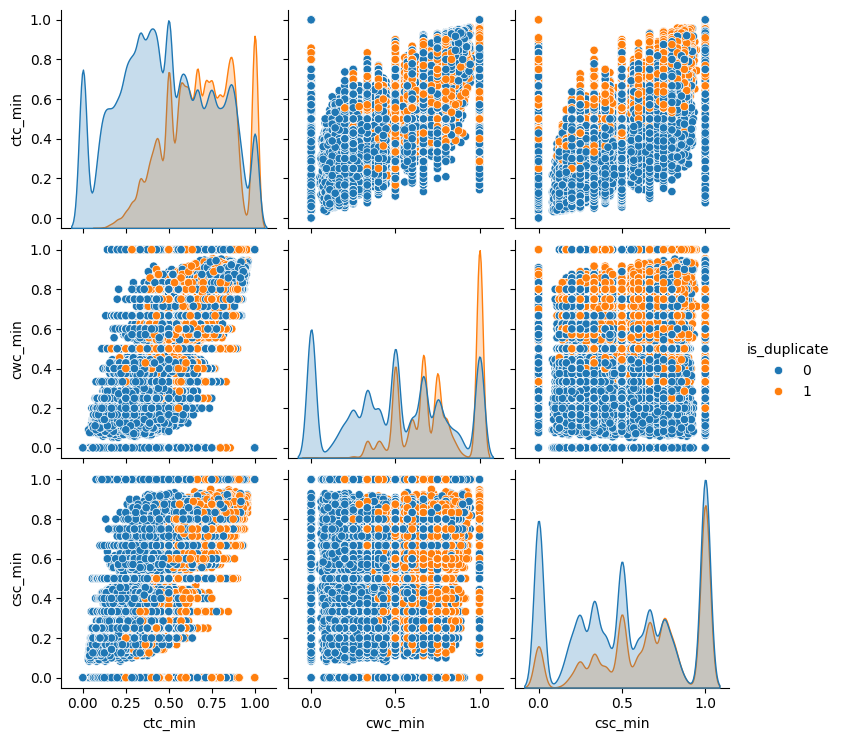

In [31]:
sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']], hue='is_duplicate')

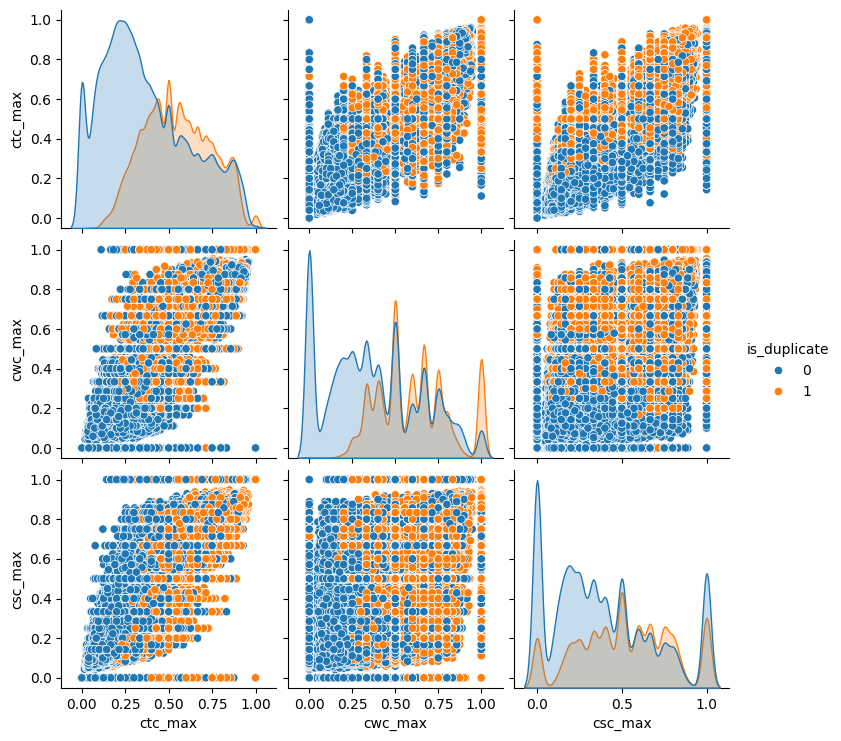

In [32]:
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']], hue='is_duplicate')

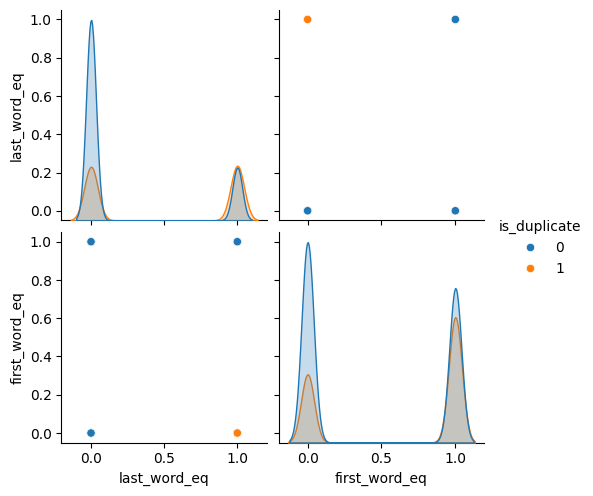

In [33]:
sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']], hue='is_duplicate')

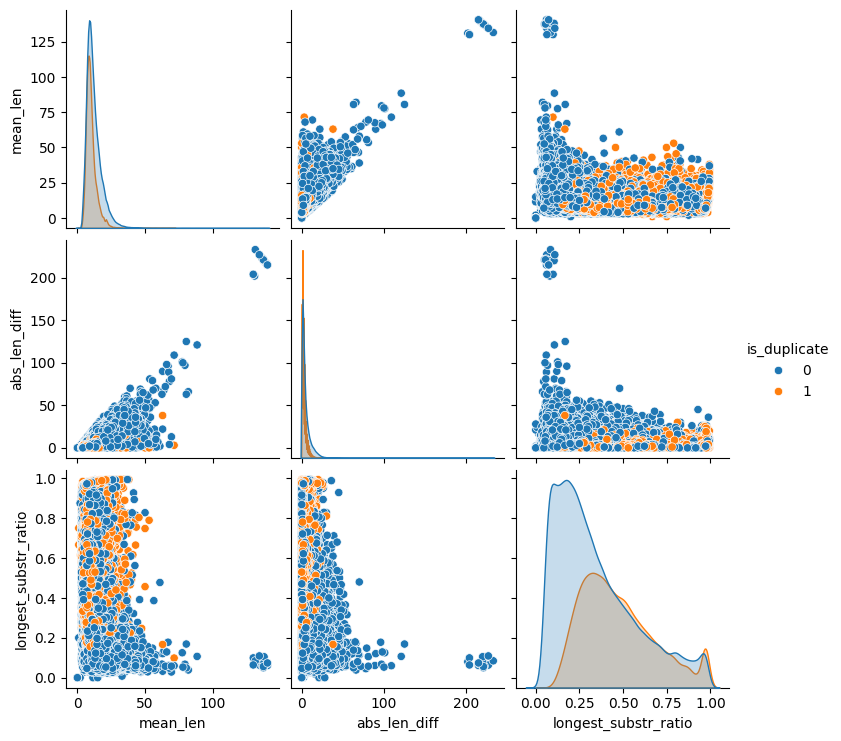

In [34]:
sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

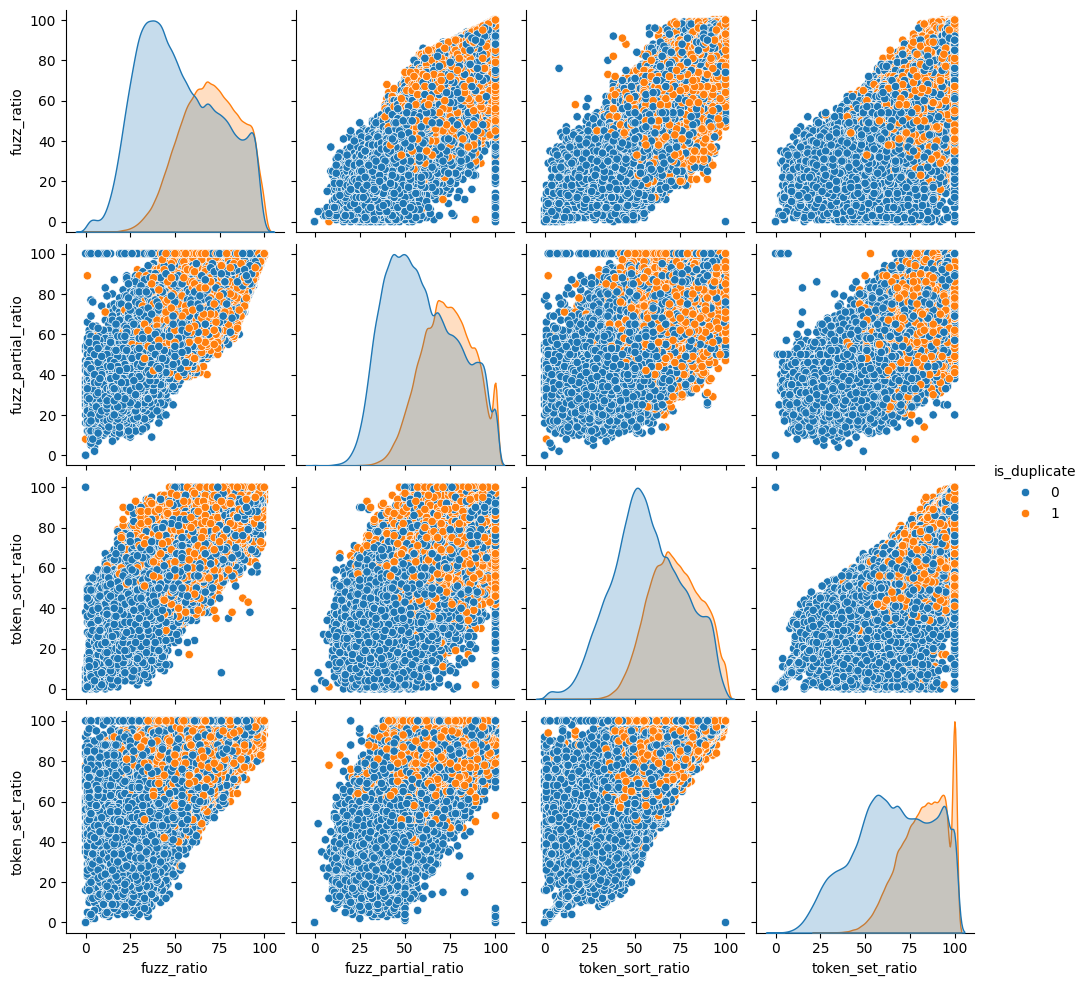

In [35]:
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [36]:
ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...
1,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...
3,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...
4,which one dissolve in water quikly sugar salt...,which fish would survive in salt water


In [37]:
final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(404351, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,65,56,14,12,11,23,0.48,0.999980,0.833319,...,0.785709,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,0,50,87,12,17,8,26,0.31,0.799984,0.399996,...,0.466664,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,0,72,58,14,10,4,24,0.17,0.399992,0.333328,...,0.285712,0.0,1.0,4.0,12.0,0.169492,43,46,63,63
3,0,49,58,12,16,1,22,0.05,0.000000,0.000000,...,0.000000,0.0,0.0,1.0,11.5,0.040000,9,11,25,28
4,0,75,38,15,7,4,21,0.19,0.399992,0.199998,...,0.307690,0.0,1.0,6.0,10.0,0.153846,35,55,47,67


In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix


questions = (
    df['question1'].fillna('').astype(str).tolist()
    + df['question2'].fillna('').astype(str).tolist()
)

cv = CountVectorizer(
    max_features=3000,
    dtype=np.int32
)

# Keep sparse
question_matrix = cv.fit_transform(questions)

n = len(df)

q1_arr = question_matrix[:n]
q2_arr = question_matrix[n:]

print("Q1 shape:", q1_arr.shape)
print("Q2 shape:", q2_arr.shape)

Q1 shape: (404351, 3000)
Q2 shape: (404351, 3000)


In [39]:
# Combine Q1 + Q2


X_bow = hstack(
    [q1_arr, q2_arr],
    format='csr'
)

print("BOW shape:", X_bow.shape)

BOW shape: (404351, 6000)


In [40]:
# 3. Reduce BOW features using TruncatedSVD
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=100,
    random_state=1
)

X_bow_reduced = svd.fit_transform(X_bow)

print("Reduced BOW shape:", X_bow_reduced.shape)

Reduced BOW shape: (404351, 100)


In [41]:
y = final_df['is_duplicate'].values

# Remove target column
handcrafted_features = final_df.drop(
    columns=['is_duplicate']
)

print("Handcrafted features shape:", handcrafted_features.shape)

Handcrafted features shape: (404351, 22)


In [42]:
# 5. Combine handcrafted + reduced BOW features

X_handcrafted = handcrafted_features.values

X = np.hstack(
    [X_handcrafted, X_bow_reduced]
)

# Reduce memory usage
X = X.astype(np.float32)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (404351, 122)
Final y shape: (404351,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (323480, 122)
X_test : (80871, 122)


In [44]:
# Create a smaller tuning dataset

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=80000,
    random_state=42,
    stratify=y_train
)

print("Tuning data:", X_tune.shape)

Tuning data: (80000, 122)


# **Random Forest**

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [46]:
rf_params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

In [47]:
# 3-fold CV + tuning

from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=1
)

rf_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=8, n_jobs=1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 150, 200]},
                   random_state=42, scoring='accuracy', verbose=1)

In [48]:
# Best parameters

print("Best RF Parameters:")
print(rf_search.best_params_)

print("Best CV Accuracy:")
print(rf_search.best_score_)

Best RF Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Accuracy:
0.7875249835271457


In [49]:
best_params = rf_search.best_params_

print(best_params)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [50]:
# Create final model

rf_final = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [51]:
rf_pred = rf_final.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("\nRandom Forest Test Accuracy:", rf_accuracy)


Random Forest Test Accuracy: 0.8117866726020452


In [52]:
from sklearn.metrics import confusion_matrix

In [53]:
# Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)
print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[43225  7785]
 [ 7436 22425]]


# **XGBoost**

In [54]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Hyperparameters
xgb_params = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=1
)

xgb_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=8, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3],
                                        'n_estimators': [100, 150, 200],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [55]:
# Best parameters

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("Best CV Accuracy:")
print(xgb_search.best_score_)

Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Accuracy:
0.7905999718092102


In [56]:
# Create final model

xgb_final = XGBClassifier(
    **xgb_search.best_params_,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1,
              num_parallel_tree=None, ...)

In [57]:
xgb_pred = xgb_final.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Test Accuracy:", xgb_accuracy)

XGBoost Test Accuracy: 0.8022406054086137


In [58]:
# XGBoost
xgb_cm = confusion_matrix(y_test, xgb_pred)
print("\nXGBoost Confusion Matrix:")
print(xgb_cm)



XGBoost Confusion Matrix:
[[43061  7949]
 [ 8044 21817]]


# **Logistic Regression**

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Hyperparameters

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "solver": ["liblinear"]
}

# GridSearchCV

lr_search = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [60]:
# Best parameters

print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

print("Best CV Accuracy:")
print(lr_search.best_score_)

Best Logistic Regression Parameters:
{'C': 1, 'class_weight': None, 'solver': 'liblinear'}
Best CV Accuracy:
0.7434875408578505


In [61]:
lr_final = LogisticRegression(
    **lr_search.best_params_,
    max_iter=1000,
    random_state=42
)

lr_final.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=1000, random_state=42, solver='liblinear')

In [62]:
lr_pred = lr_final.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Test Accuracy:", lr_accuracy)

Logistic Regression Test Accuracy: 0.7451125867121713


In [63]:
# Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)
print("\nLogistic Regression Confusion Matrix:")
print(lr_cm)


Logistic Regression Confusion Matrix:
[[42036  8974]
 [11639 18222]]


# **Linear SVM**

In [64]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    max_iter=5000,
    random_state=42
)

# Hyperparameters

svm_params = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "loss": ["squared_hinge"]
}

# GridSearchCV

svm_search = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=LinearSVC(max_iter=5000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'],
                         'loss': ['squared_hinge']},
             scoring='accuracy', verbose=1)

In [65]:
# Best parameters

print("Best SVM Parameters:")
print(svm_search.best_params_)

print("Best CV Accuracy:")
print(svm_search.best_score_)

Best SVM Parameters:
{'C': 10, 'class_weight': None, 'loss': 'squared_hinge'}
Best CV Accuracy:
0.7446625247642666


In [66]:
svm_final = LinearSVC(
    **svm_search.best_params_,
    max_iter=5000,
    random_state=42
)

svm_final.fit(X_train, y_train)

LinearSVC(C=10, max_iter=5000, random_state=42)

In [67]:
svm_pred = svm_final.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Test Accuracy:", svm_accuracy)

Linear SVM Test Accuracy: 0.7455206439885744


In [68]:
# Linear SVM
svm_cm = confusion_matrix(y_test, svm_pred)
print("\nLinear SVM Confusion Matrix:")
print(svm_cm)


Linear SVM Confusion Matrix:
[[42022  8988]
 [11592 18269]]


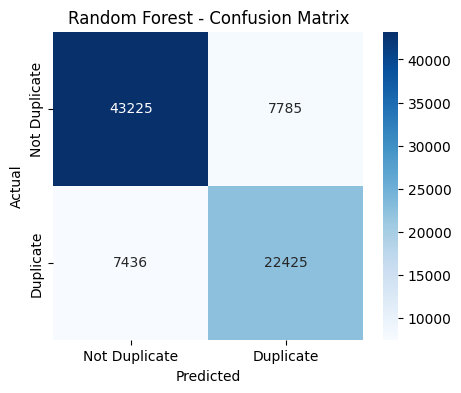

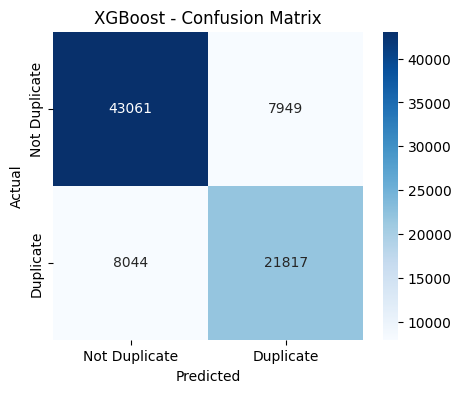

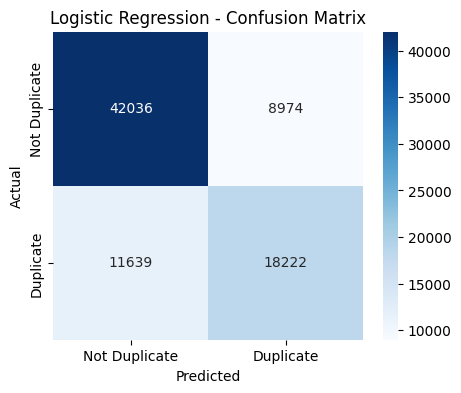

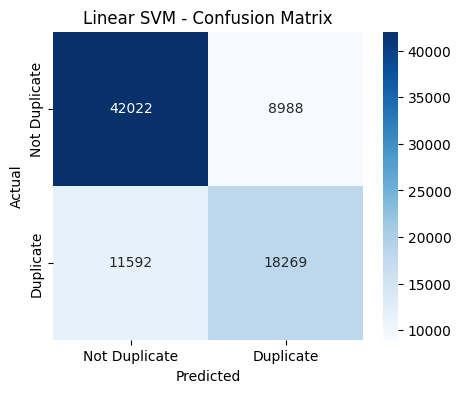

In [69]:
models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred
}

for name, pred in models.items():

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Duplicate", "Duplicate"],
        yticklabels=["Not Duplicate", "Duplicate"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred
}

results = []

for name, pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.811787,0.742304,0.750980,0.746617
1,XGBoost,0.802241,0.732950,0.730619,0.731783
2,Linear SVM,0.745521,0.670250,0.611801,0.639693
3,Logistic Regression,0.745113,0.670025,0.610227,0.638730


In [71]:
comparison_df[["Accuracy", "Precision", "Recall", "F1 Score"]] = (
    comparison_df[["Accuracy", "Precision", "Recall", "F1 Score"]] * 100
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,81.178667,74.230387,75.097954,74.661650
1,XGBoost,80.224061,73.295035,73.061853,73.178258
2,Linear SVM,74.552064,67.024984,61.180135,63.969327
3,Logistic Regression,74.511259,67.002500,61.022739,63.872969


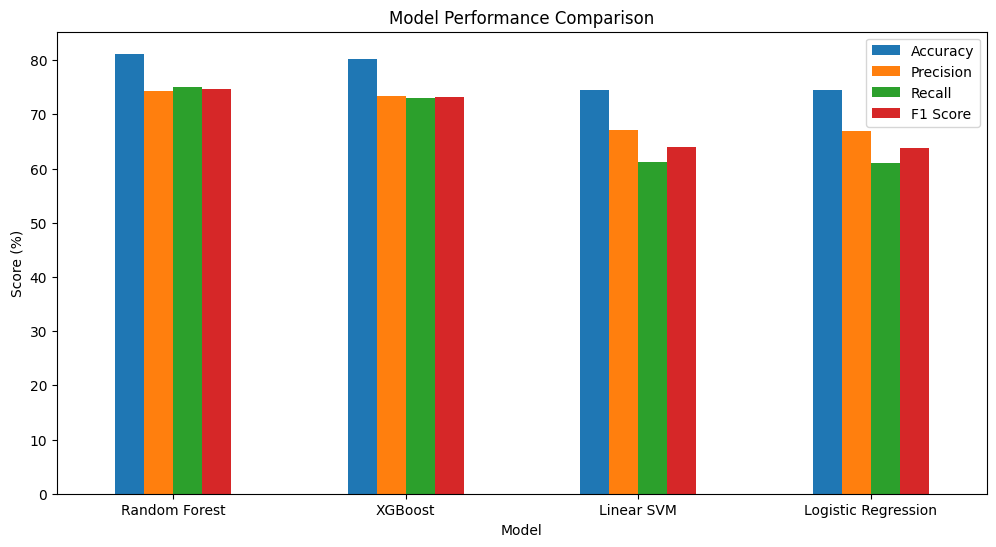

In [72]:
comparison_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# **Pickling the model**

In [73]:
import joblib

# Save final model
xgb_final.save_model(
    "duplicate_question_xgb.json"
)

# Save vectorizer
joblib.dump(cv, "count_vectorizer.pkl")

# Save SVD
joblib.dump(svd, "svd.pkl")

print("All files saved successfully!")

All files saved successfully!


In [81]:
import os

size_mb = (
    os.path.getsize("duplicate_question_xgb.json")
    / (1024 ** 2)
)

print(f"Model Size: {size_mb:.2f} MB")

Model Size: 1.75 MB
